<a href="https://colab.research.google.com/github/iris-hep/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_4_normalizing_flows_density_estimation_direct_likelihood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4 — Direct density estimation with normalizing flows

In the previous exercises we estimated density ratios directly with classifiers. Here we do a complementary exercise: train two four-member normalizing-flow ensembles,

$$
\hat p_\mathrm{sig}(x)=\frac{1}{K}\sum_{k=1}^{K}\hat p_{\mathrm{sig},k}(x),
\qquad
\hat p_\mathrm{bkg}(x)=\frac{1}{K}\sum_{k=1}^{K}\hat p_{\mathrm{bkg},k}(x),
\qquad K=4,
$$

where $x=(x_1,\ldots,x_5)$ are the reconstructed/smeared features. Each member has the same architecture used previously, while the ensemble size matches the four-member ratio corrections used in Exercise 5. We then:

1. choose either an affine-coupling RealNVP or a rational-quadratic-spline flow, and train four independently initialized members for both the background and the signal;
2. validate the learned ensemble densities using MC feature projections, the distribution of the learned log density, and, for this toy problem, the analytic smeared Gaussian-mixture truth;
3. build the likelihood **directly from the densities**, without forming density ratios and without constructing a workspace;
4. fit the signal-strength parameter $\mu$ with a small JAX likelihood;
5. use the explicit ensemble densities to generate pseudo-experiments and visualize the distribution of the likelihood-ratio test statistic.

The main pedagogical contrast is:

- classifier method: learn $p_i(x)/p_\mathrm{ref}(x)$ directly;
- flow method: learn each $p_i(x)$ directly as an equal-weight mixture of normalized flows and insert those densities in the likelihood.


In [31]:
## ============================================================================
# Google Colab setup — run me first.  Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys

# --- config -----------------------------------------------------------------
REPO_URL = "https://github.com/iris-hep/nsbi-lhc-toolkit.git"  # package + tutorial helpers
BRANCH   = "ml4hep_school_tutorial"
N_BKG, N_SIG = 100_000_000, 20_000_000     # Colab-sized dataset (raise for less MC noise in the fit)
USE_DRIVE = True                    # True -> save data/models to Google Drive so they
                                    # persist across notebooks & sessions (see notes above)
REMAKE_EVENTS = False
# ----------------------------------------------------------------------------

import subprocess
from pathlib import Path

DEPENDENCIES = [
    "pytorch-lightning",
    "onnx",
    "onnxruntime",
    "onnxscript",
    "iminuit",
    "mplhep",
    "nflows",
    "pyarrow",
]


def run(*args, env=None):
    """Run one setup command and stop immediately if it fails."""
    subprocess.run([str(arg) for arg in args], check=True, env=env)


IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab")
    else:
        ROOT = Path("/content")
    ROOT.mkdir(parents=True, exist_ok=True)

    # Keep the checkout where earlier notebook versions placed it. The source
    # helpers now live in ml4hep_tifr_colab, while the untracked legacy
    # ml4hep_tifr directory remains the persistent workspace for data/models.
    REPO_DIR = ROOT / "nsbi-lhc-toolkit"
    TUTORIAL_DIR = REPO_DIR / "workshops" / "ml4hep_tifr_colab"
    WORK_DIR = REPO_DIR / "workshops" / "ml4hep_tifr"

    if not (REPO_DIR / ".git").is_dir():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, REPO_DIR, env=clone_env,
        )
    else:
        run("git", "-C", REPO_DIR, "remote", "set-url", "origin", REPO_URL)
        run("git", "-C", REPO_DIR, "fetch", "origin", BRANCH)
        run("git", "-C", REPO_DIR, "checkout", BRANCH)
        run("git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH)

    run(
        "git", "-C", REPO_DIR, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )

    # Import package code and tutorial-local helpers from their new locations.
    for import_dir in (REPO_DIR / "src", TUTORIAL_DIR):
        import_path = str(import_dir.resolve())
        if import_path not in sys.path:
            sys.path.insert(0, import_path)

    run(sys.executable, "-m", "pip", "install", "-q", *DEPENDENCIES)

    # Preserve the exact old working location. Existing dataframes, models,
    # densities, and plots are reused; only a missing directory is created.
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK_DIR)

    remake_events = globals().get("REMAKE_EVENTS", False)
    if remake_events or not Path("dataframes/signal.parquet").exists():
        run(
            sys.executable,
            TUTORIAL_DIR / "generate_distributions.py",
            "--n_bkg", N_BKG,
            "--n_sig", N_SIG,
        )

print("Working dir:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr


## Inputs expected by this notebook

This notebook expects the updated generator output:

```text
dataframes/background.parquet
dataframes/signal.parquet
```

with both truth-level columns `z1,...,z5` and reco-level columns `x1,...,x5`.  The fit below uses only the reco-level `x*` variables.

In [32]:
import gc
import importlib
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
from scipy.special import logsumexp
from scipy.stats import multivariate_normal

import torch

import nsbi_common_utils
from utils import (
    FEATURES,
    background_components,
    density_ratio_trainer,
    predict_with_model,
    signal_components,
    smearing_parameters,
)
from utils_nf import (
    accumulate_preselection_histogram,
    choose_preselection_ratio_cut,
    collect_preselected_parquet,
    flow_log_prob_x,
    flow_sample_x,
    sample_parquet_partition,
    train_flow,
)
# A git pull can update this local helper while the notebook kernel is
# still alive. Reload it so the imported functions match the file on disk.
import utils_plotting
importlib.reload(utils_plotting)
from utils_plotting import (
    export_standalone_figure_script,
    plot_flow_pair_closure,
    plot_log_density_truth_binned,
    plot_log_density_truth_scatter,
    plot_log_prob_cdf_closure,
    plot_log_prob_closure,
    plot_mu_hat_toys,
    plot_profile_scan,
    plot_profile_scan_comparison,
    plot_t_mu_toys,
)

FEATURES = list(FEATURES)
N_DIM = len(FEATURES)

SEED = 12345
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Features: {FEATURES}")

Using device: cuda
Features: ['x1', 'x2', 'x3', 'x4', 'x5']


In [33]:
BASE_PATH = Path("./dataframes")
PRESEL_MODEL_DIR = Path("models_PRESEL")
PRESEL_PLOT_DIR = Path("plots_PRESEL")
# Keep this configuration isolated from the older single-flow/tail-3
# checkpoints. train_flow does not otherwise reject a stale compatible file.
FLOW_MODEL_DIR = Path("models_flows_preselected_spline8_tail5_ensemble4")
DENSITY_DIR = Path("saved_densities_flows_preselected_spline8_tail5_ensemble4")
PLOT_DIR = Path("plots_flows_preselected_spline8_tail5_ensemble4")
FIGURE_SCRIPT_DIR = Path("exercise4_figures_scripts")

for directory in [
    PRESEL_MODEL_DIR,
    PRESEL_PLOT_DIR,
    FLOW_MODEL_DIR,
    DENSITY_DIR,
    PLOT_DIR,
    FIGURE_SCRIPT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Rows are assigned reproducibly to independent PRESEL, flow-training, and
# evaluation partitions while the parquet files are streamed in batches.
SPLIT_SEED = 0
PRESEL_TRAIN_FRACTION = 0.5
FLOW_TRAIN_FRACTION = 0.5  # fraction of the remaining events used by the flows
STREAM_BATCH_SIZE = 100_000
PRESEL_CUT_HISTOGRAM_BINS = 4_000
PRESEL_LOG_RATIO_RANGE = (-20.0, 20.0)

# Preselection classifier choices. The classifier estimates p_signal/p_background.
PRESEL_TARGET_BACKGROUND_TO_SIGNAL_RATIO = 250.0
PRESEL_MAX_TRAIN_EVENTS_PER_CLASS = 500_000
PRESEL_HIDDEN_LAYERS = 3
PRESEL_NEURONS = 256
PRESEL_N_EPOCHS = 30
PRESEL_BATCH_SIZE = 2048
PRESEL_LEARNING_RATE = 1.0e-3
PRESEL_HOLDOUT_FRACTION = 0.25
PRESEL_VALIDATION_FRACTION = 0.20
PRESEL_PATIENCE = 8
PRESEL_LOAD_IF_AVAILABLE = True

# Select the discrete normalizing-flow architecture.
# False: affine-coupling RealNVP; True: rational-quadratic-spline couplings.
USE_QUADRATIC_SPLINE = True
FLOW_TYPE = "quadratic_spline" if USE_QUADRATIC_SPLINE else "realnvp"

# Keep these modest for a tutorial. Increase N_EPOCHS and MAX_TRAIN_EVENTS
# for tighter closure against the analytic truth.
MAX_TRAIN_EVENTS = {
    "background": 1_000_000,
    "signal": 1_000_000,
}
MAX_EVAL_EVENTS = {
    "background": 250_000,
    "signal": 250_000,
}

# Model architecture: these choices stay visible and editable for students.
N_COUPLING_LAYERS = 10
HIDDEN_FEATURES = 1024
HIDDEN_LAYERS = 4
SCALE_CLIP = 1.5                 # RealNVP only
SPLINE_NUM_BINS = 8              # quadratic-spline flow only
SPLINE_TAIL_BOUND = 5.0          # explicitly model tails through |z|=5
DROPOUT_PROBABILITY = 0.0        # spline conditioner only
FLOW_ENSEMBLE_SIZE = 4           # independently initialized members per process

# Optimizer and training choices.
BATCH_SIZE = 2048
N_EPOCHS = 70
LEARNING_RATE = 1e-4
LR_SCHEDULER_FACTOR = 0.2       # multiply LR by this when validation NLL plateaus
LR_SCHEDULER_PATIENCE = 2       # plateau epochs before reducing the LR
MIN_LEARNING_RATE = 1e-7
WEIGHT_DECAY = 0.0
VALIDATION_FRACTION = 0.20
PATIENCE = 5
GRADIENT_CLIP = 5.0

# If checkpoints already exist, load the selected architecture instead of
# retraining. RealNVP and spline checkpoints have distinct filenames.
LOAD_IF_AVAILABLE = True

MODEL_CONFIG = {
    "flow_type": FLOW_TYPE,
    "n_features": N_DIM,
    "n_coupling_layers": N_COUPLING_LAYERS,
    "hidden_features": HIDDEN_FEATURES,
    "hidden_layers": HIDDEN_LAYERS,
    "scale_clip": SCALE_CLIP,
    "spline_num_bins": SPLINE_NUM_BINS,
    "spline_tail_bound": SPLINE_TAIL_BOUND,
    "dropout_probability": DROPOUT_PROBABILITY,
}

TRAINING_CONFIG = {
    "batch_size": BATCH_SIZE,
    "n_epochs": N_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "lr_scheduler_factor": LR_SCHEDULER_FACTOR,
    "lr_scheduler_patience": LR_SCHEDULER_PATIENCE,
    "min_learning_rate": MIN_LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "validation_fraction": VALIDATION_FRACTION,
    "patience": PATIENCE,
    "gradient_clip": GRADIENT_CLIP,
}

def export_exercise4_figure(fig, script_name):
    """Export one completed figure with all of its numerical artist data."""
    return export_standalone_figure_script(
        fig,
        script_name=script_name,
        output_dir=FIGURE_SCRIPT_DIR,
    )


print(f"Standalone figure scripts will be written to {FIGURE_SCRIPT_DIR}/")
print(f"Selected flow architecture: {FLOW_TYPE}")
print(
    f"Spline bins/tail bound: {SPLINE_NUM_BINS}/{SPLINE_TAIL_BOUND:g}; "
    f"flow ensemble size per process: {FLOW_ENSEMBLE_SIZE}"
)

Selected flow architecture: quadratic_spline


### Stand-alone scripts for every figure

Immediately after constructing each figure, the notebook writes a corresponding Python script to `exercise4_figures_scripts/`. Each generated script contains a compressed copy of all numerical artist data and reconstructs the plot using only NumPy and Matplotlib—there is no dependency on this notebook, its data files, trained models, or the tutorial utilities.

The plotting commands, labels, ranges, and styles remain visible in the generated source. A marked fine-tuning block near the bottom exposes `fig` and `axes`, and running the script writes a same-named PNG next to it. The preselection training-loss script is produced only when the model is actually trained; scripts for all other displayed diagnostics are regenerated on every run.


## Stream data into independent, bounded samples

The inclusive signal-to-background ratio is deliberately left at its physical, difficult value. The parquet files are read in bounded batches, using only `x1,...,x5` and `weight`. A deterministic row hash assigns events to three disjoint roles: PRESEL-classifier training, flow training/cut selection, and final evaluation.

Only a random, capped reservoir from each role is retained in memory. Weighted yields and selection efficiencies are nevertheless accumulated over **all** streamed events, so limiting the stored Monte Carlo sample does not change the physical expected yields.

In [34]:
SAMPLE_PATHS = {
    "signal": BASE_PATH / "signal.parquet",
    "background": BASE_PATH / "background.parquet",
}

# First pass: retain only the bounded samples needed for PRESEL training.
PRESEL_signal_bce, PRESEL_signal_input_stats = sample_parquet_partition(
    SAMPLE_PATHS["signal"],
    features=FEATURES,
    partition="presel",
    max_events=PRESEL_MAX_TRAIN_EVENTS_PER_CLASS,
    batch_size=STREAM_BATCH_SIZE,
    presel_fraction=PRESEL_TRAIN_FRACTION,
    flow_train_fraction=FLOW_TRAIN_FRACTION,
    split_seed=SPLIT_SEED,
    reservoir_seed=SEED + 11,
)
PRESEL_background_bce, PRESEL_background_input_stats = sample_parquet_partition(
    SAMPLE_PATHS["background"],
    features=FEATURES,
    partition="presel",
    max_events=PRESEL_MAX_TRAIN_EVENTS_PER_CLASS,
    batch_size=STREAM_BATCH_SIZE,
    presel_fraction=PRESEL_TRAIN_FRACTION,
    flow_train_fraction=FLOW_TRAIN_FRACTION,
    split_seed=SPLIT_SEED,
    reservoir_seed=SEED + 22,
)

In [35]:
PRESEL_INPUT_STATS = {
    "signal": PRESEL_signal_input_stats,
    "background": PRESEL_background_input_stats,
}
PRESEL_INCLUSIVE_YIELD = {
    sample_name: float(stats["inclusive_weight"])
    for sample_name, stats in PRESEL_INPUT_STATS.items()
}

for sample_name, stats in PRESEL_INPUT_STATS.items():
    print(
        f"{sample_name:10s}: {stats['inclusive_events']:,} total events, "
        f"sum weights = {stats['inclusive_weight']:.6g}; "
        f"retained {stats['retained_events']:,} for PRESEL"
    )
print(
    "Inclusive B/S = "
    f"{PRESEL_INCLUSIVE_YIELD['background'] / PRESEL_INCLUSIVE_YIELD['signal']:,.1f}"
)

signal    : 20,000,000 total events, sum weights = 1100; retained 500,000 for PRESEL
background: 100,000,000 total events, sum weights = 1e+06; retained 500,000 for PRESEL
Inclusive B/S = 909.1


## Preselection with a learned density ratio

A binary classifier trained with equal total weight for signal and background estimates the density ratio

$$
r_{\rm PRESEL}(x) = \frac{p_{\rm signal}(x)}{p_{\rm background}(x)}
\simeq \frac{s(x)}{1-s(x)}.
$$

We use the repository's BCE density-ratio trainer. This first model is only a preselection tool; the final likelihood will still be constructed from the two normalizing-flow densities.

The classifier sees only the capped PRESEL reservoirs; the rest of the file is never materialized as a pandas dataframe.

In [36]:
for PRESEL_sample, PRESEL_label in [
    (PRESEL_signal_bce, 1.0),
    (PRESEL_background_bce, 0.0),
]:
    PRESEL_sample["PRESEL_label"] = PRESEL_label
    PRESEL_sample["PRESEL_weight"] = (
        PRESEL_sample["weight"] / PRESEL_sample["weight"].sum()
    )

PRESEL_training_dataframe = pd.concat(
    [PRESEL_signal_bce, PRESEL_background_bce],
    ignore_index=True,
).sample(frac=1.0, random_state=SEED, ignore_index=True)

PRESEL_trainer = density_ratio_trainer(
    dataset=PRESEL_training_dataframe,
    weights=PRESEL_training_dataframe["PRESEL_weight"].to_numpy(),
    training_labels=PRESEL_training_dataframe["PRESEL_label"].to_numpy(),
    features=FEATURES,
    features_scaling=FEATURES,
    sample_name=["signal", "background"],
    output_name="PRESEL",
    path_to_figures=f"{PRESEL_PLOT_DIR}/",
    path_to_models=f"{PRESEL_MODEL_DIR}/",
)

PRESEL_trainer.train(
    hidden_layers=PRESEL_HIDDEN_LAYERS,
    neurons=PRESEL_NEURONS,
    number_of_epochs=PRESEL_N_EPOCHS,
    batch_size=PRESEL_BATCH_SIZE,
    learning_rate=PRESEL_LEARNING_RATE,
    scalerType="MinMax",
    ensemble_index=0,
    verbose=1,
    rnd_seed=SEED,
    holdout_split=PRESEL_HOLDOUT_FRACTION,
    validation_split=PRESEL_VALIDATION_FRACTION,
    callback_patience=PRESEL_PATIENCE,
    num_workers=0,
    load_trained_models=PRESEL_LOAD_IF_AVAILABLE,
    calibration=False,
)

if PRESEL_trainer.loss_figure is not None:
    export_exercise4_figure(
        PRESEL_trainer.loss_figure,
        "training_loss_preselection",
    )

# Keep one reusable ONNX Runtime session for every streamed prediction batch.
PRESEL_scaler = PRESEL_trainer.scaler
PRESEL_model_candidate = PRESEL_trainer.model_NN
if isinstance(PRESEL_model_candidate, ort.InferenceSession):
    PRESEL_model = PRESEL_model_candidate
else:
    PRESEL_available_providers = ort.get_available_providers()
    PRESEL_providers = [
        provider
        for provider in ["CUDAExecutionProvider", "CPUExecutionProvider"]
        if provider in PRESEL_available_providers
    ]
    if not PRESEL_providers:
        PRESEL_providers = PRESEL_available_providers
    PRESEL_session_options = ort.SessionOptions()
    PRESEL_session_options.intra_op_num_threads = 1
    PRESEL_session_options.inter_op_num_threads = 1
    PRESEL_model = ort.InferenceSession(
        PRESEL_model_candidate.SerializeToString(),
        sess_options=PRESEL_session_options,
        providers=PRESEL_providers,
    )

# The trainer holds its dataset, holdout copies, and diagnostic predictions.
# None are needed once the scaler and ONNX session have been extracted.
del (
    PRESEL_trainer,
    PRESEL_model_candidate,
    PRESEL_training_dataframe,
    PRESEL_signal_bce,
    PRESEL_background_bce,
    PRESEL_sample,
)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

2026-07-12 18:51:44 | INFO | Training Logs | Reading saved models from models_PRESEL/
INFO:Training Logs:Reading saved models from models_PRESEL/
2026-07-12 18:51:50 | INFO | Training Logs | background training data has min ratio 0.005735320970416069
INFO:Training Logs:background training data has min ratio 0.005735320970416069
2026-07-12 18:51:50 | INFO | Training Logs | background training data has max ratio 31.685392379760742
INFO:Training Logs:background training data has max ratio 31.685392379760742
2026-07-12 18:51:50 | INFO | Training Logs | signal training data has min ratio 0.005920205265283585
INFO:Training Logs:signal training data has min ratio 0.005920205265283585
2026-07-12 18:51:50 | INFO | Training Logs | signal training data has max ratio 32.21379089355469
INFO:Training Logs:signal training data has max ratio 32.21379089355469
2026-07-12 18:51:50 | INFO | Training Logs | background holdout data has min ratio 0.005822719540446997
INFO:Training Logs:background holdout da

### Choose the preselection cut

We now require a sufficiently large learned ratio $r_{\rm PRESEL}(x)$. In a second streaming pass, a fine weighted histogram of $\log r_{\rm PRESEL}$ is accumulated on the future flow-training partition. The loosest histogram edge reaching the configured target $B/S$ becomes the cut; no event-by-event ratio array is retained.

A final pass evaluates that cut batch by batch, accumulates the exact selected yields, and fills bounded random reservoirs for flow training and evaluation. Each flow therefore learns the **conditional** density $p(x\mid\mathrm{pass},S)$ or $p(x\mid\mathrm{pass},B)$, and the likelihood uses the corresponding post-selection yields.

In [37]:
def evaluate_PRESEL_ratio(feature_dataframe):
    ratio = predict_with_model(
        feature_dataframe.astype("float32", copy=False),
        scaler=PRESEL_scaler,
        model=PRESEL_model,
    )
    return np.asarray(ratio, dtype=float).reshape(-1)


PRESEL_LOG_RATIO_EDGES = np.linspace(
    PRESEL_LOG_RATIO_RANGE[0],
    PRESEL_LOG_RATIO_RANGE[1],
    PRESEL_CUT_HISTOGRAM_BINS + 1,
)

# Second pass: determine the cut from small accumulated histograms.
PRESEL_signal_histogram, PRESEL_signal_hist_stats = accumulate_preselection_histogram(
    SAMPLE_PATHS["signal"],
    features=FEATURES,
    ratio_predictor=evaluate_PRESEL_ratio,
    log_ratio_edges=PRESEL_LOG_RATIO_EDGES,
    batch_size=STREAM_BATCH_SIZE,
    presel_fraction=PRESEL_TRAIN_FRACTION,
    flow_train_fraction=FLOW_TRAIN_FRACTION,
    split_seed=SPLIT_SEED,
)
PRESEL_background_histogram, PRESEL_background_hist_stats = accumulate_preselection_histogram(
    SAMPLE_PATHS["background"],
    features=FEATURES,
    ratio_predictor=evaluate_PRESEL_ratio,
    log_ratio_edges=PRESEL_LOG_RATIO_EDGES,
    batch_size=STREAM_BATCH_SIZE,
    presel_fraction=PRESEL_TRAIN_FRACTION,
    flow_train_fraction=FLOW_TRAIN_FRACTION,
    split_seed=SPLIT_SEED,
)

PRESEL_RATIO_CUT, PRESEL_CUT_DIAGNOSTICS = choose_preselection_ratio_cut(
    PRESEL_signal_histogram,
    PRESEL_background_histogram,
    PRESEL_LOG_RATIO_EDGES,
    signal_inclusive_yield=PRESEL_INCLUSIVE_YIELD["signal"],
    background_inclusive_yield=PRESEL_INCLUSIVE_YIELD["background"],
    signal_partition_weight=PRESEL_signal_hist_stats["partition_weight"],
    background_partition_weight=PRESEL_background_hist_stats["partition_weight"],
    target_background_to_signal=PRESEL_TARGET_BACKGROUND_TO_SIGNAL_RATIO,
)

# Third pass: keep only selected, capped train/evaluation reservoirs.
PRESEL_signal_samples, PRESEL_signal_stream_stats = collect_preselected_parquet(
    SAMPLE_PATHS["signal"],
    features=FEATURES,
    ratio_predictor=evaluate_PRESEL_ratio,
    ratio_cut=PRESEL_RATIO_CUT,
    max_train_events=MAX_TRAIN_EVENTS["signal"],
    max_eval_events=MAX_EVAL_EVENTS["signal"],
    batch_size=STREAM_BATCH_SIZE,
    presel_fraction=PRESEL_TRAIN_FRACTION,
    flow_train_fraction=FLOW_TRAIN_FRACTION,
    split_seed=SPLIT_SEED,
    reservoir_seed=SEED + 101,
)
PRESEL_background_samples, PRESEL_background_stream_stats = collect_preselected_parquet(
    SAMPLE_PATHS["background"],
    features=FEATURES,
    ratio_predictor=evaluate_PRESEL_ratio,
    ratio_cut=PRESEL_RATIO_CUT,
    max_train_events=MAX_TRAIN_EVENTS["background"],
    max_eval_events=MAX_EVAL_EVENTS["background"],
    batch_size=STREAM_BATCH_SIZE,
    presel_fraction=PRESEL_TRAIN_FRACTION,
    flow_train_fraction=FLOW_TRAIN_FRACTION,
    split_seed=SPLIT_SEED,
    reservoir_seed=SEED + 202,
)

PRESEL_STREAM_STATS = {
    "signal": PRESEL_signal_stream_stats,
    "background": PRESEL_background_stream_stats,
}
PRESEL_SELECTED_YIELD = {}
PRESEL_EFFICIENCY = {}
PRESEL_EVAL_YIELD_BEFORE_RESCALE = {}
for sample_name, stats in PRESEL_STREAM_STATS.items():
    train_stats = stats["flow_train"]
    eval_stats = stats["eval"]
    if train_stats["partition_weight"] <= 0.0 or eval_stats["partition_weight"] <= 0.0:
        raise RuntimeError(f"Empty streamed partition for {sample_name}.")

    PRESEL_EFFICIENCY[sample_name] = (
        train_stats["selected_weight"] / train_stats["partition_weight"]
    )
    PRESEL_SELECTED_YIELD[sample_name] = (
        PRESEL_INCLUSIVE_YIELD[sample_name] * PRESEL_EFFICIENCY[sample_name]
    )
    PRESEL_EVAL_YIELD_BEFORE_RESCALE[sample_name] = (
        PRESEL_INCLUSIVE_YIELD[sample_name]
        * eval_stats["selected_weight"]
        / eval_stats["partition_weight"]
    )

signal_train = PRESEL_signal_samples["flow_train"]
signal_eval = PRESEL_signal_samples["eval"]
background_train = PRESEL_background_samples["flow_train"]
background_eval = PRESEL_background_samples["eval"]

# Each retained reservoir represents the complete selected physical yield.
for sample_name, train_sample, eval_sample in [
    ("signal", signal_train, signal_eval),
    ("background", background_train, background_eval),
]:
    for split_name, sample in [("train", train_sample), ("eval", eval_sample)]:
        retained_weight = float(sample["weight"].sum())
        if len(sample) == 0 or retained_weight <= 0.0:
            raise RuntimeError(
                f"PRESEL retained no {sample_name} events for {split_name}."
            )
        sample["weight"] *= PRESEL_SELECTED_YIELD[sample_name] / retained_weight

TOTAL_YIELD = PRESEL_SELECTED_YIELD.copy()
PRESEL_train_background_to_signal = (
    PRESEL_SELECTED_YIELD["background"] / PRESEL_SELECTED_YIELD["signal"]
)
PRESEL_eval_background_to_signal = (
    PRESEL_EVAL_YIELD_BEFORE_RESCALE["background"]
    / PRESEL_EVAL_YIELD_BEFORE_RESCALE["signal"]
)

print(f"PRESEL ratio cut: r >= {PRESEL_RATIO_CUT:.5g}")
print(
    "Histogram estimate at the cut: B/S = "
    f"{PRESEL_CUT_DIAGNOSTICS['histogram_background_to_signal']:.2f}"
)
print(
    "Signal efficiency = "
    f"{PRESEL_EFFICIENCY['signal']:.3%}; background efficiency = "
    f"{PRESEL_EFFICIENCY['background']:.3%}"
)
print(
    f"Exact post-selection B/S: flow training = {PRESEL_train_background_to_signal:.2f}, "
    f"independent evaluation = {PRESEL_eval_background_to_signal:.2f}"
)
for sample_name, stats in PRESEL_STREAM_STATS.items():
    print(
        f"{sample_name:10s}: retained "
        f"{stats['flow_train']['retained_events']:,}/"
        f"{stats['flow_train']['selected_events']:,} selected train events and "
        f"{stats['eval']['retained_events']:,}/"
        f"{stats['eval']['selected_events']:,} selected eval events"
    )
print("Post-selection yields:", TOTAL_YIELD)

del (
    PRESEL_signal_samples,
    PRESEL_background_samples,
    PRESEL_signal_histogram,
    PRESEL_background_histogram,
    PRESEL_model,
    PRESEL_scaler,
)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

PRESEL ratio cut: r >= 2.0751
Histogram estimate at the cut: B/S = 249.76
Signal efficiency = 55.618%; background efficiency = 15.280%
Exact post-selection B/S: flow training = 249.76, independent evaluation = 250.03
signal    : retained 1,000,000/2,780,813 selected train events and 250,000/2,777,892 selected eval events
background: retained 1,000,000/3,819,357 selected train events and 250,000/3,819,527 selected eval events
Post-selection yields: {'signal': 611.801619020227, 'background': 152803.41655546872}


## Choose and train the final normalizing-flow ensembles

The implementation of each individual flow is kept in `utils_nf.py` so that this workshop notebook can focus on the statistical ideas. The ensemble construction is deliberately notebook-local and therefore does not alter the behavior of any other exercise. The boolean `USE_QUADRATIC_SPLINE` above selects one of two **discrete normalizing flows**:

- **RealNVP:** affine coupling transforms with alternating binary masks;
- **quadratic spline:** piecewise rational-quadratic coupling transforms, which can represent more flexible monotonic maps within each coupling layer.

Each process density is the arithmetic mean of four independently initialized, individually normalized members. It is therefore itself normalized. Numerically, its log density is evaluated as

$$
\log\hat p_{\rm ens}(x)
=\operatorname{logsumexp}_{k=1,\ldots,K}
 \left[\log\hat p_k(x)\right]-\log K,
$$

rather than by averaging the member log densities. Samples are drawn from the same mixture by choosing a member uniformly for each event.

All members are trained only on events passing PRESEL, by maximizing the exact log likelihood

$$
\log \hat p_k(x) = \log p_Z\big(f_k(x)\big)
+ \log\left|\det\frac{\partial f_k}{\partial x}\right|.
$$

For numerical stability, each member standardizes its training sample independently. The utility functions include the corresponding standardization Jacobian when evaluating a density, so the notebook-local ensemble evaluator always returns $\log \hat p_{\rm ens}(x)$ in the original `x` coordinates.


### Train the signal and background flow ensembles

The architecture and optimizer settings are passed explicitly from the notebook to `train_flow`. The learning rate is reduced when the validation NLL stops improving, allowing finer optimization near convergence without freezing training on a fixed schedule. The inputs here are the post-selection signal and background samples.

The four members of each process use different initialization, subsampling, and train-validation seeds. Their checkpoints have member-specific names inside the versioned `models_flows_preselected_spline8_tail5_ensemble4/` directory, so the older single-flow, tail-bound-three checkpoints cannot be loaded accidentally.


In [38]:
def ensemble_flow_log_prob_x(flow_ensemble, x, batch_size=65_536):
    """Evaluate the log density of an equal-weight normalized flow mixture."""
    if not flow_ensemble:
        raise ValueError("The flow ensemble must contain at least one member.")

    member_log_probabilities = np.stack(
        [
            np.asarray(
                flow_log_prob_x(member, x, batch_size=batch_size),
                dtype=np.float64,
            )
            for member in flow_ensemble
        ],
        axis=0,
    )
    return logsumexp(member_log_probabilities, axis=0) - np.log(
        len(flow_ensemble)
    )


_FLOW_ENSEMBLE_SAMPLING_RNG = np.random.default_rng(SEED + 9_001)


def ensemble_flow_sample_x(
    flow_ensemble,
    n,
    batch_size=65_536,
    rng=None,
):
    """Sample the same equal-weight mixture used by the ensemble density."""
    if not flow_ensemble:
        raise ValueError("The flow ensemble must contain at least one member.")

    n = int(n)
    if n < 0:
        raise ValueError("n must be non-negative.")
    if n == 0:
        return np.empty(
            (0, len(flow_ensemble[0]["features"])),
            dtype=np.float32,
        )

    allocation_rng = _FLOW_ENSEMBLE_SAMPLING_RNG if rng is None else rng
    probabilities = np.full(
        len(flow_ensemble),
        1.0 / len(flow_ensemble),
        dtype=np.float64,
    )
    member_counts = allocation_rng.multinomial(n, probabilities)
    chunks = [
        flow_sample_x(member, int(member_count), batch_size=batch_size)
        for member, member_count in zip(flow_ensemble, member_counts)
        if member_count
    ]
    samples = np.concatenate(chunks, axis=0).astype(np.float32, copy=False)
    allocation_rng.shuffle(samples, axis=0)
    return samples


flows = {}
flow_training_samples = {
    "background": background_train,
    "signal": signal_train,
}
del background_train, signal_train

for sample_name, base_seed in [("background", 101), ("signal", 202)]:
    sample_train = flow_training_samples.pop(sample_name)
    flows[sample_name] = []

    for ensemble_index in range(FLOW_ENSEMBLE_SIZE):
        member_seed = base_seed + 1_000 * ensemble_index
        torch.manual_seed(member_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(member_seed)

        member = train_flow(
            f"{sample_name}_member_{ensemble_index:02d}",
            sample_train,
            features=FEATURES,
            model_dir=FLOW_MODEL_DIR,
            model_config=MODEL_CONFIG,
            training_config=TRAINING_CONFIG,
            device=device,
            max_train_events=MAX_TRAIN_EVENTS[sample_name],
            load_if_available=LOAD_IF_AVAILABLE,
            seed=member_seed,
        )
        flows[sample_name].append(member)
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(
        f"{sample_name}: trained/loaded "
        f"{len(flows[sample_name])} flow members"
    )
    del sample_train
    gc.collect()

# Training data are no longer needed after all flow checkpoints exist.
del flow_training_samples
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Loading existing background flow from models_flows_preselected/quadratic_spline_background.pt
Loading existing signal flow from models_flows_preselected/quadratic_spline_signal.pt


## Validation 1: feature and correlation closure

A flow must reproduce not only every one-dimensional feature distribution, but also the dependence among features. The pair plot below summarizes both:

- **diagonal:** overlaid one-dimensional densities for held-out MC and flow-generated events;
- **lower triangle:** shared-range two-dimensional density contours enclosing approximately 68% and 95% of each sample;
- **upper triangle:** the Pearson correlations $\rho_\mathrm{MC}$ and $\rho_\mathrm{flow}$, together with $\Delta\rho = \rho_\mathrm{flow}-\rho_\mathrm{MC}$.

The contours are particularly important: matching all diagonal projections does not guarantee that the flow ensemble has learned the joint five-dimensional structure.

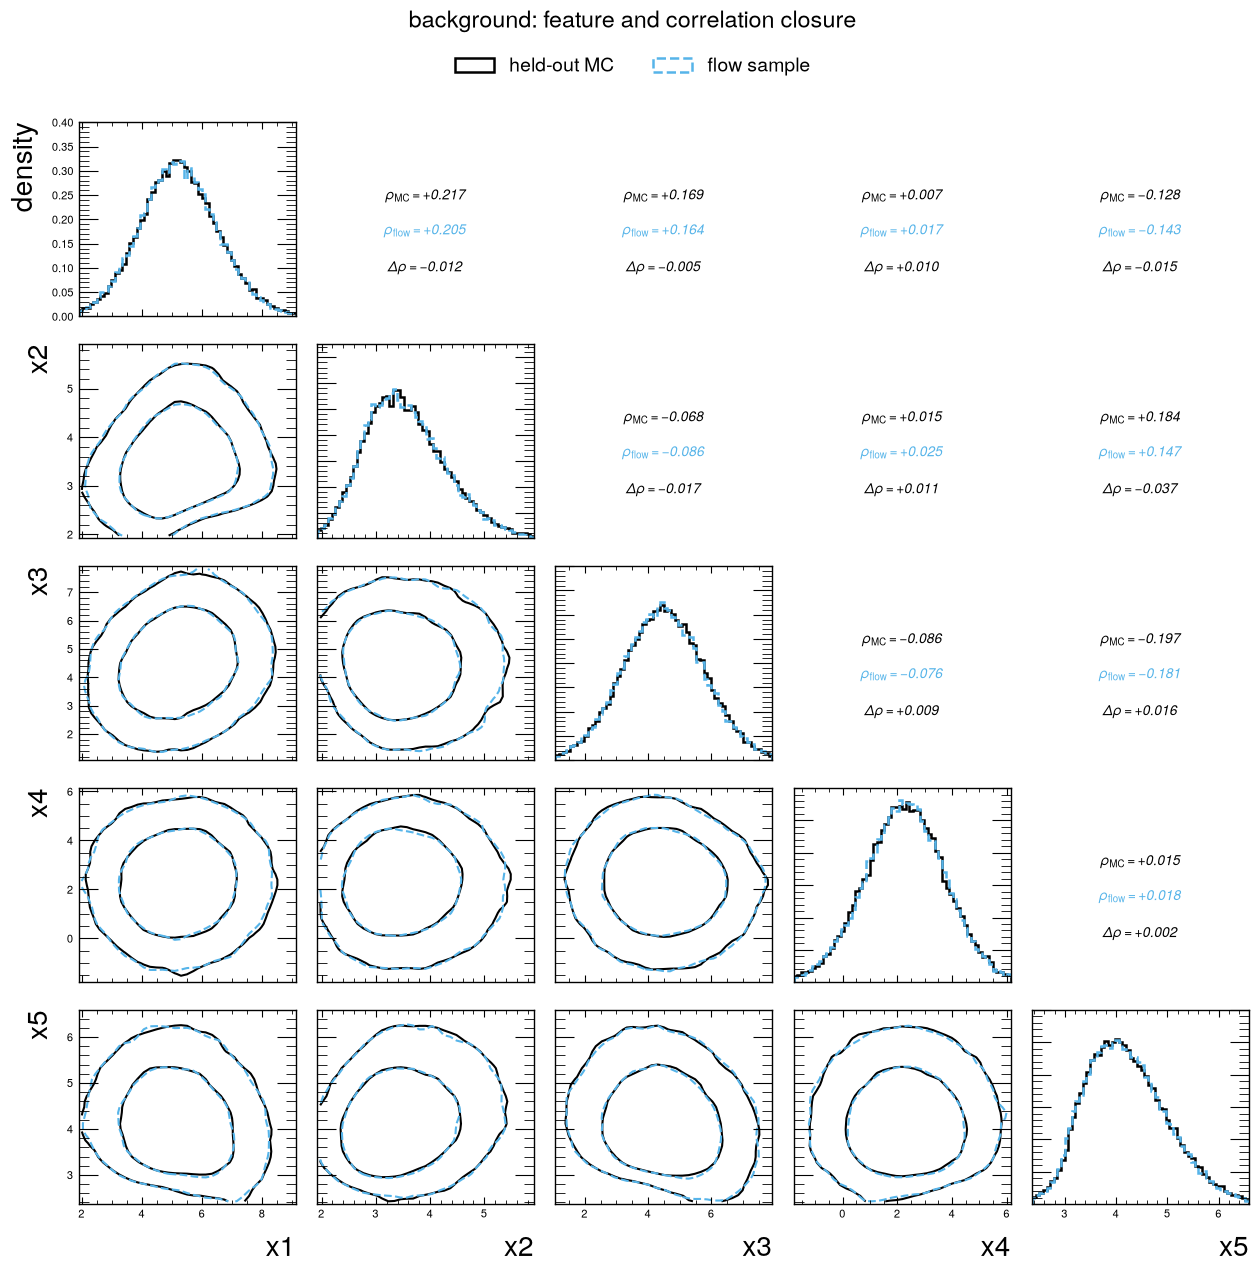

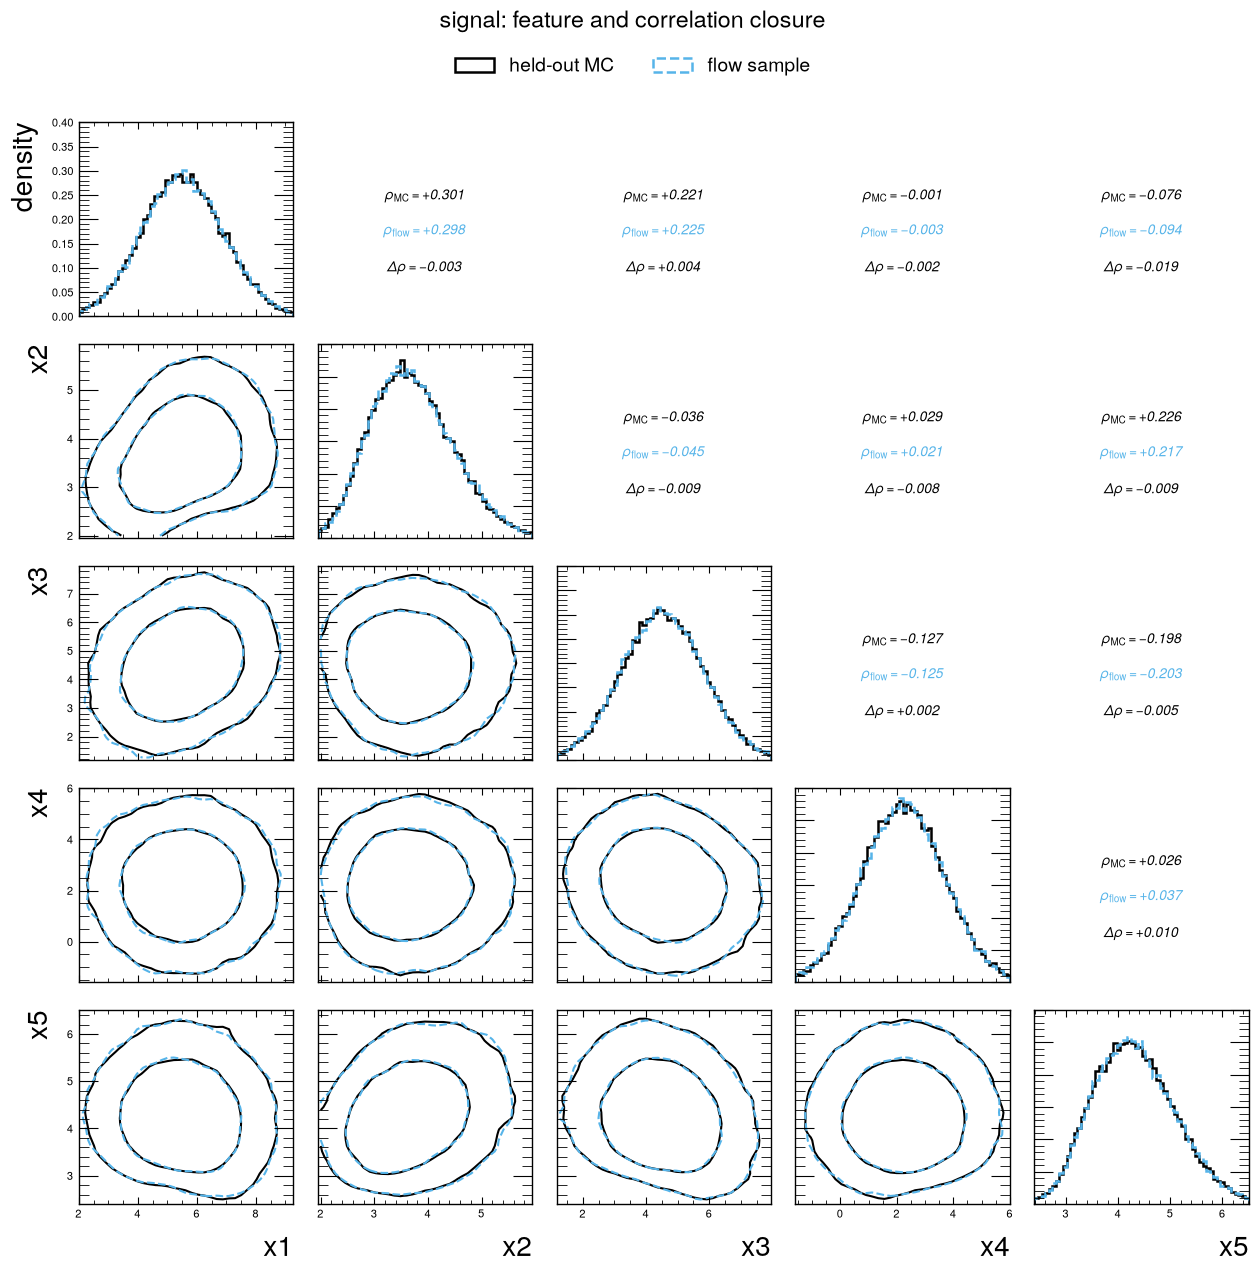

In [39]:
def sample_flow_pair_closure(df_eval, flow_ensemble, n_plot=50_000):
    """Prepare held-out and generated event arrays for the pair plot."""
    n_plot = min(int(n_plot), len(df_eval))
    mc = df_eval.sample(n=n_plot, random_state=SEED)[FEATURES].to_numpy(dtype=np.float32)
    generated = ensemble_flow_sample_x(flow_ensemble, n_plot)
    return mc, generated


background_pair_mc, background_pair_generated = sample_flow_pair_closure(
    background_eval, flows["background"]
)
fig = plot_flow_pair_closure(
    "background",
    background_pair_mc,
    background_pair_generated,
    FEATURES,
)
export_exercise4_figure(
    fig,
    "background_feature_correlation_closure",
)
plt.show()

signal_pair_mc, signal_pair_generated = sample_flow_pair_closure(
    signal_eval, flows["signal"]
)
fig = plot_flow_pair_closure(
    "signal",
    signal_pair_mc,
    signal_pair_generated,
    FEATURES,
)
export_exercise4_figure(
    fig,
    "signal_feature_correlation_closure",
)
plt.show()

## Validation 2: closure as a function of the learned log density

The five reconstructed variables can also be compressed to the scalar learned log density

$$
\ell(x) = \log \hat p_\mathrm{flow}(x).
$$

Below, we evaluate the **same trained flow ensemble** on two sets of events: held-out MC events and events sampled from the ensemble. If the learned density reproduces the data distribution, the two distributions of $\ell(x)$ should agree.

The generated reference uses many more events by default than the held-out MC points. Its finite-sampling fluctuations are therefore small, and the visible statistical uncertainty is dominated by the finite MC evaluation sample. The lower panel shows the bin-by-bin ratio $\mathrm{MC}/\mathrm{flow}$; its error bars include the finite counts in both histograms, although the high-statistics flow contribution is small. This does **not** remove uncertainty or bias in the trained ensemble itself; it only makes the numerical sampling of that fixed ensemble very precise.

### CDF-versus-CDF closure

The same comparison can be displayed as a probability–probability (P–P) plot. For common thresholds in $\ell=\log \hat p(x)$, we plot the empirical MC CDF against the flow CDF,

$$
F_\mathrm{MC}(\ell) \quad\text{versus}\quad F_\mathrm{flow}(\ell).
$$

Perfect closure therefore follows the diagonal $F_\mathrm{MC}=F_\mathrm{flow}$. The lower panel shows the ratio $F_\mathrm{MC}/F_\mathrm{flow}$; the scan starts at $F_\mathrm{flow}=10^{-3}$ to avoid division by zero. The blue bands are the approximate pointwise $\pm1\sigma$ finite-sample expectations; neighboring CDF points are correlated, and the bands do not include flow-training uncertainty.

This remains a one-dimensional projection. It is a useful and sensitive diagnostic, but agreement here alone does not prove complete five-dimensional closure because different regions of feature space can have the same value of $\log \hat p(x)$.

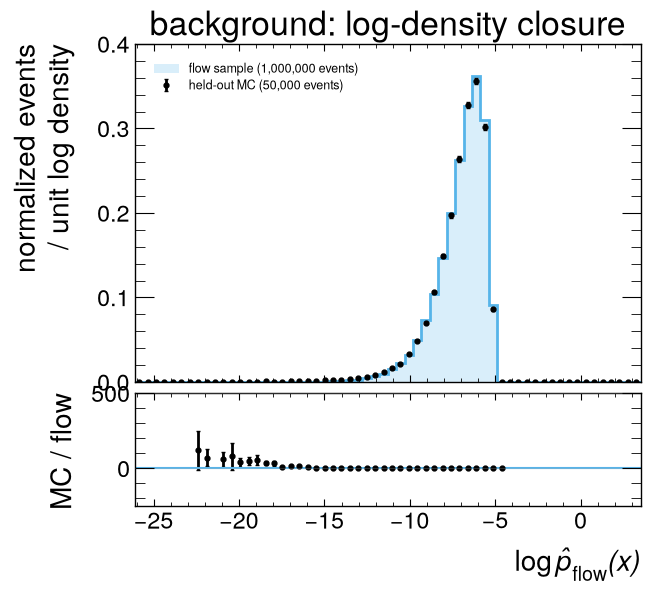

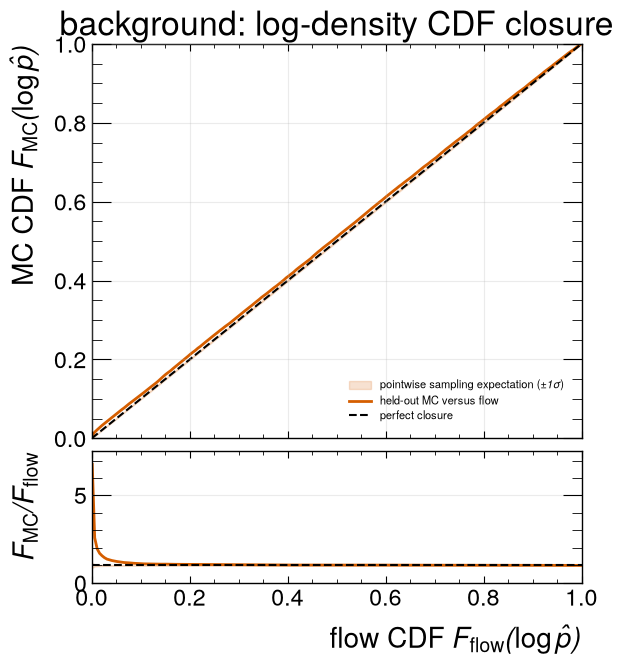

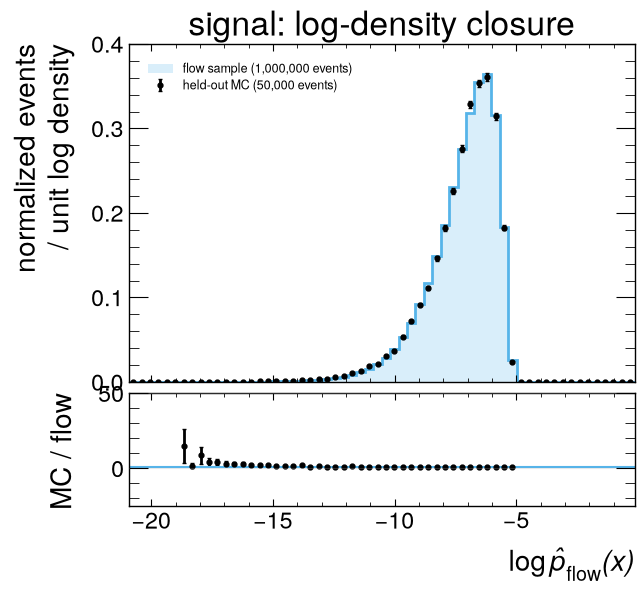

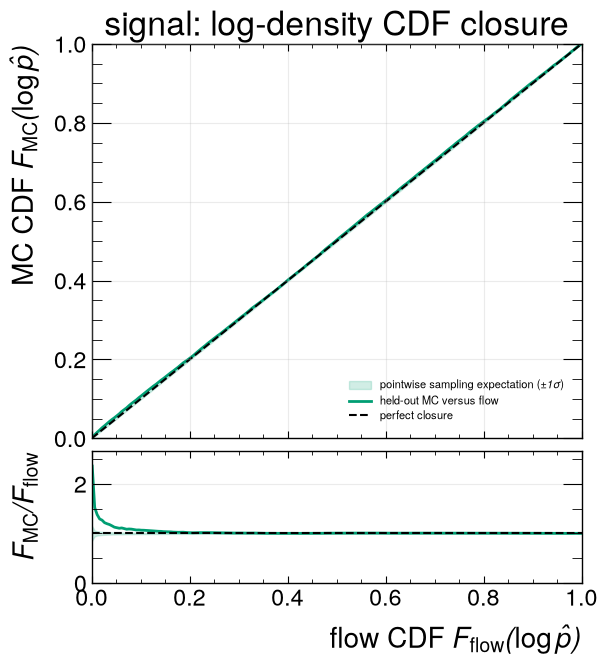

In [40]:
def evaluate_log_prob_closure(
    df_eval,
    flow_ensemble,
    n_mc=50_000,
    n_flow_samples=1_000_000,
):
    """Prepare learned log densities for held-out and generated events."""
    n_mc = min(int(n_mc), len(df_eval))
    mc_events = df_eval.sample(n=n_mc, random_state=SEED)[FEATURES]
    log_p_mc = ensemble_flow_log_prob_x(flow_ensemble, mc_events)

    # A much larger generated reference makes its finite-sampling noise small
    # compared with that of the held-out MC sample.
    generated_events = ensemble_flow_sample_x(flow_ensemble, int(n_flow_samples))
    log_p_generated = ensemble_flow_log_prob_x(flow_ensemble, generated_events)
    del generated_events

    log_p_mc = log_p_mc[np.isfinite(log_p_mc)]
    log_p_generated = log_p_generated[np.isfinite(log_p_generated)]
    if len(log_p_mc) == 0 or len(log_p_generated) == 0:
        raise ValueError("The flow returned no finite log-probability values.")
    return log_p_mc, log_p_generated


background_log_p_mc, background_log_p_generated = evaluate_log_prob_closure(
    background_eval, flows["background"]
)
fig = plot_log_prob_closure(
    "background", background_log_p_mc, background_log_p_generated
)
export_exercise4_figure(fig, "background_log_density_closure")
plt.show()
cdf_fig = plot_log_prob_cdf_closure(
    "background", background_log_p_mc, background_log_p_generated, color="C0"
)
export_exercise4_figure(cdf_fig, "background_log_density_cdf_closure")
plt.show()

signal_log_p_mc, signal_log_p_generated = evaluate_log_prob_closure(
    signal_eval, flows["signal"]
)
fig = plot_log_prob_closure(
    "signal", signal_log_p_mc, signal_log_p_generated
)
export_exercise4_figure(fig, "signal_log_density_closure")
plt.show()
cdf_fig = plot_log_prob_cdf_closure(
    "signal", signal_log_p_mc, signal_log_p_generated, color="C4"
)
export_exercise4_figure(cdf_fig, "signal_log_density_cdf_closure")
plt.show()

## Validation 3: compare with the analytic smeared truth

For the generator, the truth-level variables are Gaussian mixtures in $y$.  The reco variables are generated as

$$
x = D y + \epsilon, \qquad \epsilon_i \sim \mathcal{N}(0, \sigma_{\mathrm{res},i}^2),
$$

where $D = \mathrm{diag}(\mathrm{scale})$.  Therefore each Gaussian component remains Gaussian after smearing:

$$
\mu_x = D\mu_y, \qquad \Sigma_x = D\Sigma_yD^T + \mathrm{diag}(\sigma_\mathrm{res}^2).
$$

This analytic truth is only available because the tutorial toy model is simple.  It is useful here as a clean closure check of the flow-ensemble density itself.

Because the flows are trained after PRESEL, this comparison uses the analytic density conditional on passing the cut. On selected events this is $p(x\mid\mathrm{pass})=p(x)/\epsilon_{\rm PRESEL}$, where the efficiency is estimated from the independent flow-training pool.

In [41]:
def reco_components_from_truth_components(components):
    scale, resolution = smearing_parameters()
    scale = np.asarray(scale, dtype=float)
    resolution = np.asarray(resolution, dtype=float)
    D = np.diag(scale)
    response_cov = np.diag(resolution ** 2)

    reco_components = []
    for frac, mean_y, cov_y in components:
        mean_x = scale * np.asarray(mean_y, dtype=float)
        cov_x = D @ np.asarray(cov_y, dtype=float) @ D.T + response_cov
        reco_components.append((frac, mean_x, cov_x))
    return reco_components


def mixture_log_density(x, components):
    x = np.asarray(x, dtype=float)
    fracs = np.asarray([c[0] for c in components], dtype=float)
    fracs = fracs / fracs.sum()

    terms = []
    for f, (_, mean, cov) in zip(fracs, components):
        terms.append(
            np.log(f) + multivariate_normal(mean=mean, cov=cov, allow_singular=False).logpdf(x)
        )
    return logsumexp(np.vstack(terms), axis=0)


TRUTH_RECO_COMPONENTS = {
    "background": reco_components_from_truth_components(background_components()),
    "signal": reco_components_from_truth_components(signal_components()),
}


def selected_mixture_log_density(x, sample_name):
    """Analytic reco density conditional on passing the PRESEL cut."""
    return (
        mixture_log_density(x, TRUTH_RECO_COMPONENTS[sample_name])
        - np.log(PRESEL_EFFICIENCY[sample_name])
    )

background: corr(log p) = 0.9599, RMSE = 0.5150, bias = -0.0470


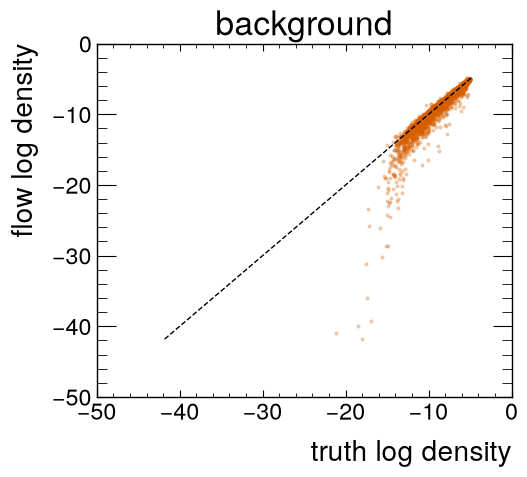

signal: corr(log p) = 0.9874, RMSE = 0.2405, bias = -0.0229


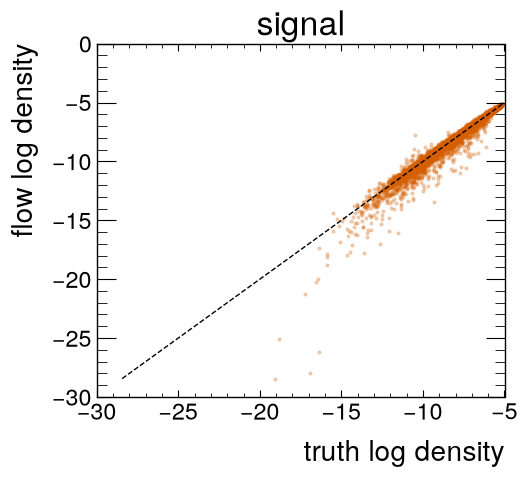

In [42]:
def evaluate_log_density_truth(sample_name, df_eval, flow_ensemble, n_points=25_000):
    """Prepare analytic and learned log-density arrays."""
    n_points = min(n_points, len(df_eval))
    x = df_eval.sample(n=n_points, random_state=SEED)[FEATURES].to_numpy(dtype=np.float32)
    log_p_flow = ensemble_flow_log_prob_x(flow_ensemble, x)
    log_p_truth = selected_mixture_log_density(x, sample_name)
    delta = log_p_flow - log_p_truth

    corr = np.corrcoef(log_p_truth, log_p_flow)[0, 1]
    rmse = np.sqrt(np.mean(delta**2))
    bias = np.mean(delta)
    print(f"{sample_name}: corr(log p) = {corr:.4f}, RMSE = {rmse:.4f}, bias = {bias:.4f}")
    return log_p_truth, log_p_flow


background_log_p_truth, background_log_p_flow = evaluate_log_density_truth(
    "background", background_eval, flows["background"]
)
fig = plot_log_density_truth_scatter(
    "background", background_log_p_truth, background_log_p_flow
)
export_exercise4_figure(
    fig,
    "background_log_density_truth_scatter",
)
plt.show()

signal_log_p_truth, signal_log_p_flow = evaluate_log_density_truth(
    "signal", signal_eval, flows["signal"]
)
fig = plot_log_density_truth_scatter(
    "signal", signal_log_p_truth, signal_log_p_flow
)
export_exercise4_figure(
    fig,
    "signal_log_density_truth_scatter",
)
plt.show()

In [43]:
def build_log_density_truth_calibration(
    sample_name,
    df_eval,
    flow_ensemble,
    n_points=100_000,
    n_bins=25,
    binning="quantile",
):
    """Evaluate probabilities and aggregate their residuals in truth bins."""
    n_points = min(n_points, len(df_eval))
    x = df_eval.sample(n=n_points, random_state=SEED)[FEATURES].to_numpy(dtype=np.float32)
    log_p_flow = ensemble_flow_log_prob_x(flow_ensemble, x)
    log_p_truth = selected_mixture_log_density(x, sample_name)
    delta = log_p_flow - log_p_truth

    if binning == "quantile":
        edges = np.unique(np.quantile(log_p_truth, np.linspace(0.0, 1.0, n_bins + 1)))
    elif binning == "uniform":
        edges = np.linspace(log_p_truth.min(), log_p_truth.max(), n_bins + 1)
    else:
        edges = np.asarray(binning, dtype=float)
    if len(edges) < 3:
        raise ValueError("Need at least two non-empty bins for the calibration plot.")

    eps = 1.0e-9 * max(1.0, float(edges[-1] - edges[0]))
    edges = edges.astype(float).copy()
    edges[0] -= eps
    edges[-1] += eps
    bin_index = np.searchsorted(edges, log_p_truth, side="right") - 1
    bin_index = np.clip(bin_index, 0, len(edges) - 2)

    rows = []
    for i in range(len(edges) - 1):
        mask = bin_index == i
        count = int(mask.sum())
        if count == 0:
            rows.append(
                {
                    "bin": i,
                    "truth_lo": edges[i],
                    "truth_hi": edges[i + 1],
                    "count": 0,
                    "truth_mean": np.nan,
                    "flow_mean": np.nan,
                    "flow_sem": np.nan,
                    "delta_mean": np.nan,
                    "delta_sem": np.nan,
                }
            )
            continue

        flow_std = log_p_flow[mask].std(ddof=1) if count > 1 else 0.0
        delta_std = delta[mask].std(ddof=1) if count > 1 else 0.0
        rows.append(
            {
                "bin": i,
                "truth_lo": edges[i],
                "truth_hi": edges[i + 1],
                "count": count,
                "truth_mean": log_p_truth[mask].mean(),
                "flow_mean": log_p_flow[mask].mean(),
                "flow_sem": flow_std / np.sqrt(count),
                "delta_mean": delta[mask].mean(),
                "delta_sem": delta_std / np.sqrt(count),
            }
        )

    calibration = pd.DataFrame(rows)
    valid = calibration["count"] > 0
    binned_bias = np.average(
        calibration.loc[valid, "delta_mean"],
        weights=calibration.loc[valid, "count"],
    )
    binned_rms = np.sqrt(
        np.average(
            calibration.loc[valid, "delta_mean"] ** 2,
            weights=calibration.loc[valid, "count"],
        )
    )
    max_abs_bias = np.nanmax(np.abs(calibration.loc[valid, "delta_mean"]))
    print(
        f"{sample_name}: binned bias = {binned_bias:.4f}, "
        f"binned RMS bias = {binned_rms:.4f}, "
        f"max |bin bias| = {max_abs_bias:.4f}"
    )
    return calibration, edges, log_p_truth, log_p_flow

background: binned bias = -0.0502, binned RMS bias = 0.1968, max |bin bias| = 0.9758


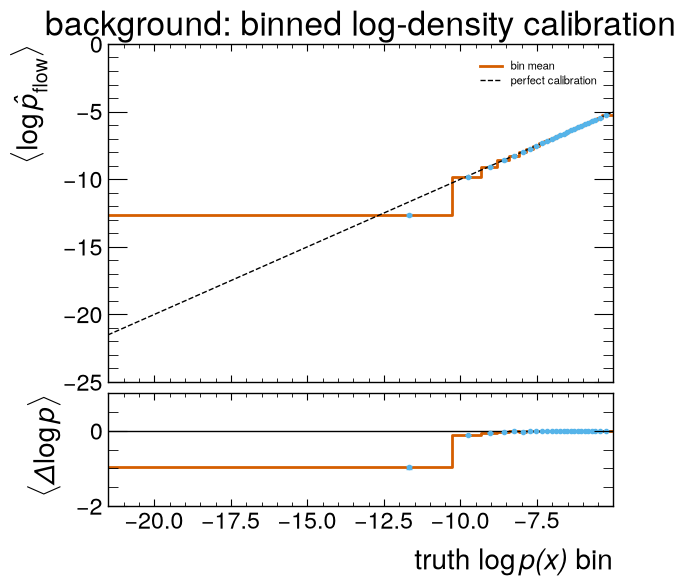

signal: binned bias = -0.0238, binned RMS bias = 0.0637, max |bin bias| = 0.3051


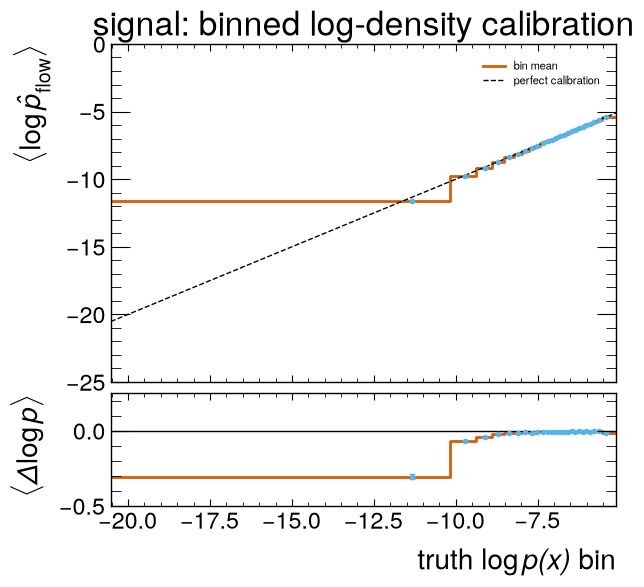

In [44]:
(
    background_logp_calibration,
    background_logp_edges,
    background_logp_truth_binned,
    background_logp_flow_binned,
) = build_log_density_truth_calibration(
    "background", background_eval, flows["background"]
)
fig = plot_log_density_truth_binned(
    "background",
    background_logp_calibration,
    background_logp_edges,
    background_logp_truth_binned,
    background_logp_flow_binned,
)
export_exercise4_figure(
    fig,
    "background_log_density_truth_binned",
)
plt.show()

(
    signal_logp_calibration,
    signal_logp_edges,
    signal_logp_truth_binned,
    signal_logp_flow_binned,
) = build_log_density_truth_calibration(
    "signal", signal_eval, flows["signal"]
)
fig = plot_log_density_truth_binned(
    "signal",
    signal_logp_calibration,
    signal_logp_edges,
    signal_logp_truth_binned,
    signal_logp_flow_binned,
)
export_exercise4_figure(
    fig,
    "signal_log_density_truth_binned",
)
plt.show()

## Direct likelihood from the learned densities

Because the flow ensembles estimate the post-selection densities $p_\mathrm{sig}(x\mid\mathrm{pass})$ and $p_\mathrm{bkg}(x\mid\mathrm{pass})$ directly, we do **not** need to choose a reference density or train another density-ratio estimator.

Using the post-selection yields $\lambda_\mathrm{sig}$ and $\lambda_\mathrm{bkg}$, the extended unbinned likelihood contains the event intensity

$$
\nu(x\mid\mu)
= \mu\lambda_\mathrm{sig}\hat p_\mathrm{sig}(x)
+ \lambda_\mathrm{bkg}\hat p_\mathrm{bkg}(x),
$$

and, up to constants independent of $\mu$,

$$
-2\log L(\mu)
= -2\sum_i w_i\log\nu(x_i\mid\mu)
+2\left(\mu\lambda_\mathrm{sig}+\lambda_\mathrm{bkg}\right).
$$

Normalizing flows naturally return $\log\hat p(x)$. Exponentiating a very negative `float32` log density can produce an exact zero, so the mixture is evaluated directly in log space:

$$
\log\nu(x\mid\mu)
= \operatorname{logaddexp}\!\left(
\log\mu+\log\lambda_\mathrm{sig}+\log\hat p_\mathrm{sig}(x),
\log\lambda_\mathrm{bkg}+\log\hat p_\mathrm{bkg}(x)
\right).
$$

This is algebraically the same direct-density likelihood, but it remains stable even when one component density is extremely small.

In [45]:
asimov_dataset = pd.concat(
    [background_eval, signal_eval],
    ignore_index=True,
).copy()
weights_asimov = asimov_dataset["weight"].to_numpy(dtype=np.float64)
X_asimov = asimov_dataset[FEATURES].to_numpy(dtype=np.float32)

lam_sig = float(TOTAL_YIELD["signal"])
lam_bkg = float(TOTAL_YIELD["background"])

# Keep the learned densities in log space. Cast the log values—not their
# exponentials—to float64 before passing them to JAX.
log_p_sig_flow = np.asarray(
    ensemble_flow_log_prob_x(flows["signal"], X_asimov),
    dtype=np.float64,
)
log_p_bkg_flow = np.asarray(
    ensemble_flow_log_prob_x(flows["background"], X_asimov),
    dtype=np.float64,
)

In [46]:
# Analytic post-selection log densities for the truth comparison.
log_p_sig_truth = np.asarray(
    selected_mixture_log_density(X_asimov, "signal"),
    dtype=np.float64,
)
log_p_bkg_truth = np.asarray(
    selected_mixture_log_density(X_asimov, "background"),
    dtype=np.float64,
)

LOG_DENSITIES = {
    "flow signal": log_p_sig_flow,
    "flow background": log_p_bkg_flow,
    "truth signal": log_p_sig_truth,
    "truth background": log_p_bkg_truth,
}
for density_name, values in LOG_DENSITIES.items():
    if not np.all(np.isfinite(values)):
        raise RuntimeError(f"{density_name} contains non-finite log densities.")
    print(
        f"{density_name:16s}: dtype={values.dtype}, "
        f"range=[{values.min():.3f}, {values.max():.3f}]"
    )

flow signal     : dtype=float64, range=[-131.373, -5.022]
flow background : dtype=float64, range=[-136.548, -4.603]
truth signal    : dtype=float64, range=[-24.114, -5.099]
truth background: dtype=float64, range=[-22.822, -5.006]


## Fit $\mu$ and construct the profile-likelihood-ratio test statistic

The normalizing flows provide the event densities, while JAX provides the likelihood gradient. Minimizing $\mathrm{NLL}=-2\log L$ gives the maximum-likelihood estimate $\hat\mu$. To test a fixed value of $\mu$, we use the **profile likelihood ratio**

$$
t_\mu = -2\log\lambda(\mu)
= -2\log\frac{L(\mu,\hat{\hat{\boldsymbol\theta}}_\mu)}{L(\hat\mu,\hat{\boldsymbol\theta})}
= \mathrm{NLL}(\mu,\hat{\hat{\boldsymbol\theta}}_\mu)-\mathrm{NLL}(\hat\mu,\hat{\boldsymbol\theta}).
$$

Here $\boldsymbol\theta$ denotes nuisance parameters, and $\hat{\hat{\boldsymbol\theta}}_\mu$ is their conditional best fit at fixed $\mu$. This exercise has no nuisance parameters, so the profiling is trivial. The scan below constructs the test-statistic curve $t_\mu$, whose minimum is $t_{\hat\mu}=0$.

In [47]:
EPS = 1.0e-300  # used only as a positive floor for mu at the physical boundary
INVALID_NLL = 1.0e30


def make_direct_log_density_nll(
    log_p_sig_np,
    log_p_bkg_np,
    weights_np,
    lam_sig_value,
    lam_bkg_value,
):
    """Build the extended direct-density NLL entirely in log space."""
    log_p_sig_np = np.asarray(log_p_sig_np, dtype=np.float64)
    log_p_bkg_np = np.asarray(log_p_bkg_np, dtype=np.float64)
    weights_np = np.asarray(weights_np, dtype=np.float64)
    lam_sig_value = float(lam_sig_value)
    lam_bkg_value = float(lam_bkg_value)

    if log_p_sig_np.shape != log_p_bkg_np.shape or log_p_sig_np.shape != weights_np.shape:
        raise ValueError("Signal, background, and weight arrays must have equal shape.")
    if lam_sig_value <= 0.0 or lam_bkg_value <= 0.0:
        raise ValueError("Expected signal and background yields must be positive.")
    if not (
        np.all(np.isfinite(log_p_sig_np))
        and np.all(np.isfinite(log_p_bkg_np))
        and np.all(np.isfinite(weights_np))
    ):
        raise ValueError("Log densities and event weights must be finite.")
    if np.any(weights_np < 0.0):
        raise ValueError("This Asimov likelihood requires non-negative weights.")

    log_sig_intensity = jnp.asarray(
        np.log(lam_sig_value) + log_p_sig_np,
        dtype=jnp.float64,
    )
    log_bkg_intensity = jnp.asarray(
        np.log(lam_bkg_value) + log_p_bkg_np,
        dtype=jnp.float64,
    )
    weights_j = jnp.asarray(weights_np, dtype=jnp.float64)

    def _nll(params):
        mu = params[0]
        safe_mu = jnp.maximum(mu, EPS)
        log_event_intensity = jnp.logaddexp(
            log_bkg_intensity,
            jnp.log(safe_mu) + log_sig_intensity,
        )
        n_expected = mu * lam_sig_value + lam_bkg_value
        nll = (
            -2.0 * jnp.sum(weights_j * log_event_intensity)
            + 2.0 * n_expected
        )

        invalid = (mu < 0.0) | (n_expected <= 0.0) | (~jnp.isfinite(nll))
        negative_mu = jnp.minimum(mu, 0.0)
        penalty = INVALID_NLL * (1.0 + negative_mu**2)
        return jnp.where(invalid, penalty, nll)

    return _nll


nll_manual = make_direct_log_density_nll(
    log_p_sig_flow,
    log_p_bkg_flow,
    weights_asimov,
    lam_sig,
    lam_bkg,
)

inf_manual = nsbi_common_utils.inference.inference(
    model_nll=jax.jit(nll_manual),
    initial_values=[1.0],
    list_parameters=["mu"],
    num_unconstrained_params=1,
    model_grad=jax.jit(jax.grad(nll_manual)),
)

print("\n" + "=" * 40)
print(" DIRECT FLOW-DENSITY FIT RESULTS ")
print("=" * 40 + "\n")
inf_manual.perform_fit(freeze_params=[])
mu_min = inf_manual.pulls_global_fit


 DIRECT FLOW-DENSITY FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.163e+06                 │         Nfcn = 27, Ngrad = 2         │
│ EDM = 2.86e-07 (Goal: 0.0002)    │            time = 1.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬─────────

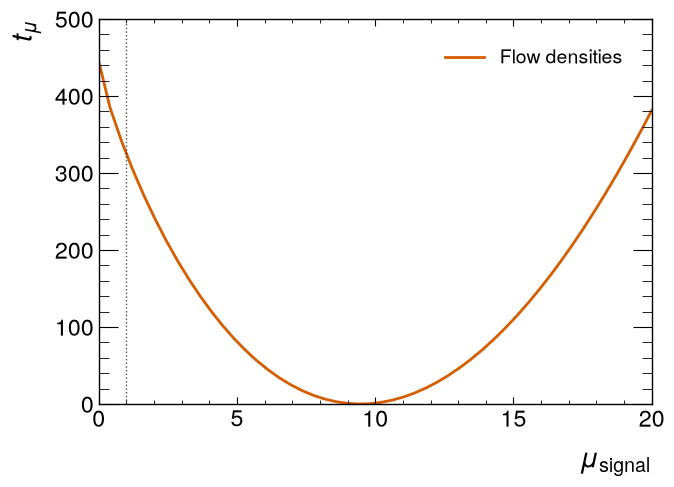

In [50]:
SCAN_RANGE = (0.0, 20.0)
scan_flow, tmu_flow = inf_manual.perform_profile_scan(
    parameter_name="mu",
    freeze_params=[],
    bound_range=SCAN_RANGE,
    fit_strategy=0,
    size=50,
)

fig = plot_profile_scan(scan_flow, tmu_flow, label="Flow ensembles")
export_exercise4_figure(fig, "flow_profile_likelihood_scan")
plt.show()


 ANALYTIC RECO-DENSITY FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.178e+06                 │         Nfcn = 20, Ngrad = 1         │
│ EDM = 4.06e-07 (Goal: 0.0002)    │            time = 1.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬───────

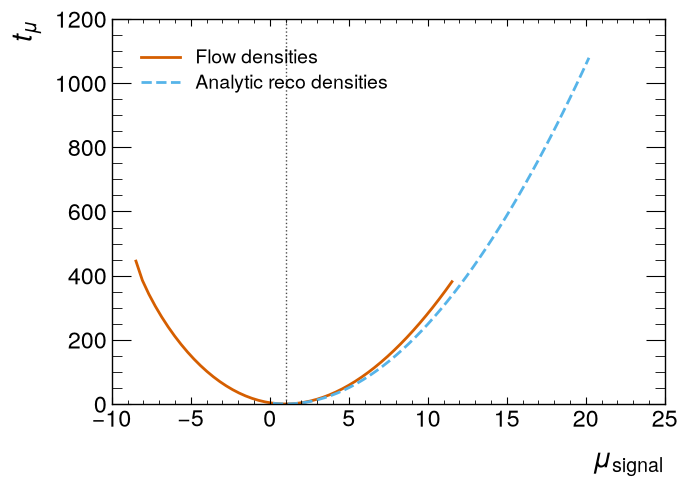

In [51]:
nll_truth = make_direct_log_density_nll(
    log_p_sig_truth,
    log_p_bkg_truth,
    weights_asimov,
    lam_sig,
    lam_bkg,
)

inf_truth = nsbi_common_utils.inference.inference(
    model_nll=jax.jit(nll_truth),
    initial_values=[1.0],
    list_parameters=["mu"],
    num_unconstrained_params=1,
    model_grad=jax.jit(jax.grad(nll_truth)),
)

print("\n" + "=" * 40)
print(" ANALYTIC RECO-DENSITY FIT RESULTS ")
print("=" * 40 + "\n")
inf_truth.perform_fit(freeze_params=[])
mu_min_truth = inf_truth.pulls_global_fit

scan_truth, tmu_truth = inf_truth.perform_profile_scan(
    parameter_name="mu",
    freeze_params=[],
    bound_range=SCAN_RANGE,
    fit_strategy=0,
    size=50,
)

fig = plot_profile_scan_comparison(
    scan_flow,
    tmu_flow,
    mu_min,
    scan_truth,
    tmu_truth,
    mu_min_truth,
)
export_exercise4_figure(fig, "flow_vs_analytic_profile_likelihood")
plt.show()

## Sampling distributions from pseudo-experiments

For each hypothesis $\mu=0$ and $\mu=1$, a toy first draws its total event count from $\mathrm{Poisson}(\mu\lambda_S+\lambda_B)$. Each event is then labeled signal or background with the corresponding mixture probability and sampled from that process's equal-weight four-flow ensemble. Finally, the toy is fitted with the same ensemble density, JAX likelihood, and Minuit interface used above, giving one value of $\hat\mu$ and $t_\mu$.

Repeating this construction produces the sampling distributions below, which we compare with the asymptotic Wilks/Cowan predictions.


JAX toy padding size: 156,581 events
mu=0: completed 10/100 toys
mu=0: completed 20/100 toys
mu=0: completed 30/100 toys
mu=0: completed 40/100 toys
mu=0: completed 50/100 toys
mu=0: completed 60/100 toys
mu=0: completed 70/100 toys
mu=0: completed 80/100 toys
mu=0: completed 90/100 toys
mu=0: completed 100/100 toys
mu=1: completed 10/100 toys
mu=1: completed 20/100 toys
mu=1: completed 30/100 toys
mu=1: completed 40/100 toys
mu=1: completed 50/100 toys
mu=1: completed 60/100 toys
mu=1: completed 70/100 toys
mu=1: completed 80/100 toys
mu=1: completed 90/100 toys
mu=1: completed 100/100 toys
Asymptotic sigma_mu estimates: {0.0: np.float64(0.49408027109375097), 1.0: np.float64(0.4708700475373419)}
           mu_hat                t_mu             n_events            
             mean       std      mean       std       mean         std
mu_true                                                               
0.0      0.128403  0.230002  0.271572  0.692369  152799.77  360.587115
1.0      0

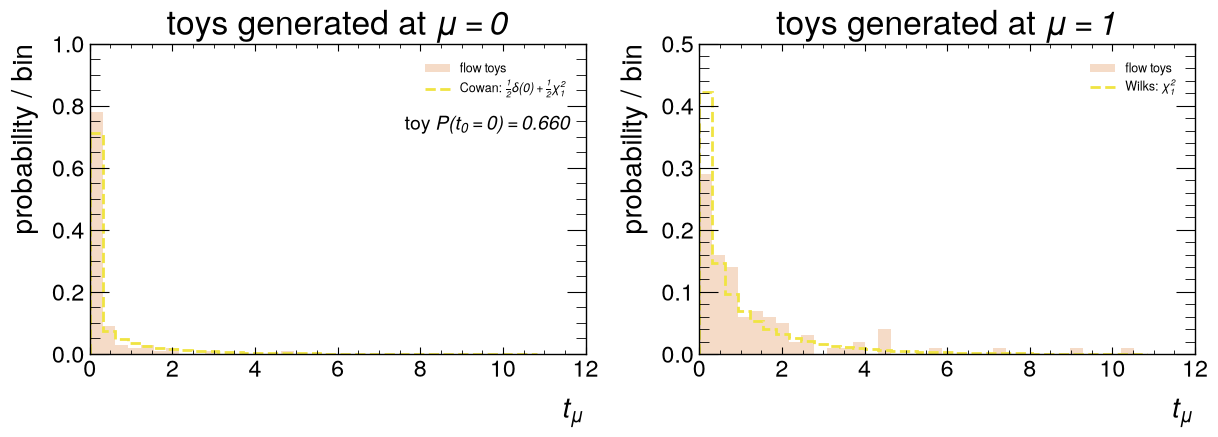

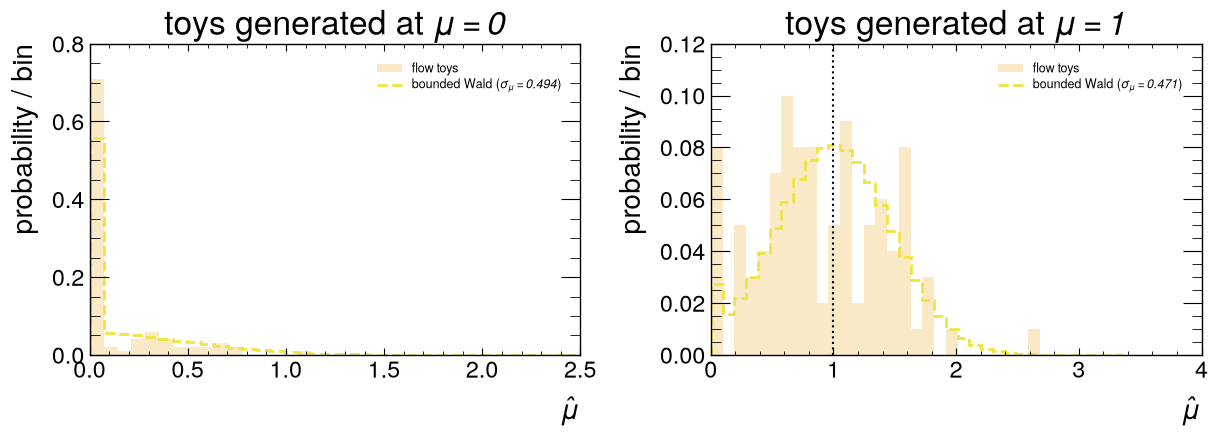

In [52]:
# =============================================================================
# Toy distributions of t_mu and mu_hat
# =============================================================================
# These toys are generated from the trained flow ensembles and fitted with
# the same ensemble densities. They test the statistical construction and the Wilks/Cowan limits
# under the learned model; they do not test misspecification of that model.

from contextlib import nullcontext, redirect_stdout
from io import StringIO

N_TOYS = 100                 # use 20 for a quick test; increase for smooth plots
TOY_HYPOTHESES = (0.0, 1.0)
TOY_SEED = 314159
TOY_FLOW_BATCH_SIZE = 65_536
TOY_PLOT_BINS = 35
TOY_VERBOSE_FITS = False      # True prints the Minuit table for every toy
TOY_PADDING_SIGMAS = 8.0      # common JAX shape; Poisson overflow is negligible

TOY_MAX_EXPECTED_EVENTS = max(
    mu * lam_sig + lam_bkg for mu in TOY_HYPOTHESES
)
TOY_PAD_SIZE = int(
    np.ceil(
        TOY_MAX_EXPECTED_EVENTS
        + TOY_PADDING_SIGMAS * np.sqrt(TOY_MAX_EXPECTED_EVENTS)
        + 32
    )
)
print(f"JAX toy padding size: {TOY_PAD_SIZE:,} events")


def generate_flow_toy(
    mu_true,
    flow_ensembles,
    lam_sig_value,
    lam_bkg_value,
    rng,
    batch_size=65_536,
):
    """Generate one extended toy dataset from the signal/background ensembles."""
    mu_true = float(mu_true)
    if mu_true < 0.0:
        raise ValueError("mu_true must be non-negative.")

    n_expected = mu_true * lam_sig_value + lam_bkg_value
    n_total = int(rng.poisson(n_expected))
    signal_fraction = (
        mu_true * lam_sig_value / n_expected if n_expected > 0.0 else 0.0
    )
    n_signal = int(rng.binomial(n_total, signal_fraction))
    n_background = n_total - n_signal

    samples = []
    if n_background:
        samples.append(
            ensemble_flow_sample_x(
                flow_ensembles["background"],
                n_background,
                batch_size=batch_size,
                rng=rng,
            )
        )
    if n_signal:
        samples.append(
            ensemble_flow_sample_x(
                flow_ensembles["signal"],
                n_signal,
                batch_size=batch_size,
                rng=rng,
            )
        )

    if samples:
        x_toy = np.concatenate(samples, axis=0).astype(np.float32, copy=False)
    else:
        x_toy = np.empty((0, len(FEATURES)), dtype=np.float32)

    # Event order is irrelevant for an unbinned likelihood, so no expensive
    # million-row shuffle is needed.
    return x_toy, n_total, n_signal, n_background



def _toy_relative_nll(params, q_padded, lam_sig_value, lam_bkg_value):
    """-2 log L up to background-only constants, for one padded toy."""
    mu = params[0]
    event_factor = 1.0 + mu * q_padded
    n_expected = mu * lam_sig_value + lam_bkg_value
    nll = 2.0 * (
        mu * lam_sig_value
        - jnp.sum(jnp.log(jnp.maximum(event_factor, EPS)))
    )
    invalid = (n_expected <= 0.0) | jnp.any(event_factor <= 0.0)
    return jnp.where(invalid, 1.0e30 + 1.0e12 * mu**2, nll)


# All toys have the same padded shape, so JAX compiles these kernels only once.
TOY_NLL_KERNEL = jax.jit(_toy_relative_nll)
TOY_GRAD_KERNEL = jax.jit(jax.grad(_toy_relative_nll, argnums=0))


def fit_flow_toy(
    x_toy,
    test_mu,
    flow_ensembles,
    lam_sig_value,
    lam_bkg_value,
    batch_size=65_536,
):
    """Fit one toy with the common JAX/Minuit inference interface."""
    if len(x_toy) == 0:
        return 0.0, 2.0 * float(test_mu) * lam_sig_value, 0.0
    if len(x_toy) > TOY_PAD_SIZE:
        raise RuntimeError(
            f"Toy has {len(x_toy):,} events, above TOY_PAD_SIZE={TOY_PAD_SIZE:,}. "
            "Increase TOY_PADDING_SIGMAS."
        )

    log_p_sig_toy = ensemble_flow_log_prob_x(
        flow_ensembles["signal"], x_toy, batch_size=batch_size
    ).astype(np.float64, copy=False)
    log_p_bkg_toy = ensemble_flow_log_prob_x(
        flow_ensembles["background"], x_toy, batch_size=batch_size
    ).astype(np.float64, copy=False)

    # q_i is the signal/background intensity ratio. Background-only constants
    # cancel, reducing the JAX input from two density arrays to one ratio array.
    log_q = (
        np.log(lam_sig_value / lam_bkg_value)
        + log_p_sig_toy
        - log_p_bkg_toy
    )
    q = np.exp(np.clip(log_q, -80.0, 80.0))
    del log_p_sig_toy, log_p_bkg_toy, log_q

    q_padded = np.zeros(TOY_PAD_SIZE, dtype=np.float64)
    q_padded[: len(q)] = q
    q_jax = jnp.asarray(q_padded)
    del q_padded

    def toy_nll(params):
        return TOY_NLL_KERNEL(params, q_jax, lam_sig_value, lam_bkg_value)

    def toy_grad(params):
        return TOY_GRAD_KERNEL(params, q_jax, lam_sig_value, lam_bkg_value)

    toy_inference = nsbi_common_utils.inference.inference(
        model_nll=toy_nll,
        initial_values=[max(0.1, float(test_mu))],
        list_parameters=["mu"],
        num_unconstrained_params=1,
        model_grad=toy_grad,
    )

    # Minuit first finds the unconstrained one-dimensional optimum. Since this
    # likelihood is convex, imposing mu >= 0 is simply a projection to zero.
    fit_output = nullcontext() if TOY_VERBOSE_FITS else redirect_stdout(StringIO())
    with fit_output:
        toy_inference.perform_fit(fit_strategy=0, freeze_params=[])
    mu_unconstrained = float(np.asarray(toy_inference.pulls_global_fit).reshape(-1)[0])
    mu_hat = max(0.0, mu_unconstrained)

    # Evaluate the likelihood-ratio difference in NumPy after the Minuit fit.
    # This avoids retaining a JAX object from each toy.
    test_mu = float(test_mu)
    t_mu = 2.0 * (
        (test_mu - mu_hat) * lam_sig_value
        - np.sum(np.log1p(test_mu * q) - np.log1p(mu_hat * q))
    )
    t_mu = max(0.0, float(t_mu))

    response = q / (1.0 + test_mu * q)
    observed_information = float(np.sum(response**2))
    return mu_hat, t_mu, observed_information


def run_flow_toys(
    mu_true,
    n_toys,
    flow_ensembles,
    lam_sig_value,
    lam_bkg_value,
    seed,
    batch_size=65_536,
):
    """Generate and fit a sequence of toys while keeping memory bounded."""
    n_toys = int(n_toys)
    if n_toys < 1:
        raise ValueError("n_toys must be positive.")

    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    rows = []
    progress_every = max(1, n_toys // 10)
    for toy_index in range(n_toys):
        x_toy, n_total, n_signal, n_background = generate_flow_toy(
            mu_true,
            flow_ensembles,
            lam_sig_value,
            lam_bkg_value,
            rng,
            batch_size=batch_size,
        )
        mu_hat, t_mu, information = fit_flow_toy(
            x_toy,
            mu_true,
            flow_ensembles,
            lam_sig_value,
            lam_bkg_value,
            batch_size=batch_size,
        )
        rows.append(
            {
                "mu_true": float(mu_true),
                "toy": toy_index,
                "n_events": n_total,
                "n_signal": n_signal,
                "n_background": n_background,
                "mu_hat": mu_hat,
                "t_mu": t_mu,
                "information": information,
            }
        )
        del x_toy

        if (toy_index + 1) % progress_every == 0 or toy_index + 1 == n_toys:
            print(f"mu={mu_true:g}: completed {toy_index + 1}/{n_toys} toys")

    return pd.DataFrame(rows)


def asymptotic_sigmas(toy_results):
    """Estimate the expected Wald sigma from the mean observed information."""
    sigmas = {}
    for mu_true, group in toy_results.groupby("mu_true"):
        mean_information = float(group["information"].mean())
        sigmas[float(mu_true)] = 1.0 / np.sqrt(mean_information)
    return sigmas


toy_results = pd.concat(
    [
        run_flow_toys(
            mu_true,
            N_TOYS,
            flows,
            lam_sig,
            lam_bkg,
            seed=TOY_SEED + int(1000 * mu_true),
            batch_size=TOY_FLOW_BATCH_SIZE,
        )
        for mu_true in TOY_HYPOTHESES
    ],
    ignore_index=True,
)

sigma_by_mu = asymptotic_sigmas(toy_results)
print("Asymptotic sigma_mu estimates:", sigma_by_mu)
print(
    toy_results.groupby("mu_true")[["mu_hat", "t_mu", "n_events"]]
    .agg(["mean", "std"])
    .to_string()
)

fig = plot_t_mu_toys(toy_results, n_bins=TOY_PLOT_BINS)
export_exercise4_figure(fig, "toy_test_statistic_distributions")
plt.show()

fig = plot_mu_hat_toys(toy_results, sigma_by_mu, n_bins=TOY_PLOT_BINS)
export_exercise4_figure(fig, "toy_signal_strength_distributions")
plt.show()

## Suggested exercises

1. Toggle `USE_QUADRATIC_SPLINE`, retrain the two flow ensembles, and compare the validation plots with the RealNVP result.
2. Vary the ensemble size, number of coupling layers, hidden-layer width, and spline bins to study the trade-off between expressivity and training time.
3. Train on truth-level `y*` variables instead of reco-level `x*` variables and compare how detector smearing changes the achievable sensitivity.
